In [1]:
# Given a saved dataframe with all seeds and their corresponding policies, recover the latents

In [2]:
# do autoreload
%load_ext autoreload
%autoreload 2

from training.LatentPrediction import Latent, DataPoint, LatentPredictionDataset
import torch
from pathlib import Path

In [3]:
from diffusers import AutoPipelineForText2Image
pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")
torch.cuda.empty_cache()
pipe.to("cuda")
print("Loaded pipe!")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pipe!


In [ ]:
from PIL import Image
def generate_image(prompt: str, latent: Latent) -> Image.Image:
    return pipe(
        prompt=prompt,
        num_images_per_prompt=1,
        latents=latent.unsqueeze(0), # must unsqueeze
        width=512,
        height=512,
        num_inference_steps=1,
        guidance_scale=0.0,
    ).images[0]

In [4]:
def get_latent_lists_from_seeds(seeds: list[int]) -> list[Latent]:
    generators = [torch.Generator(device="cpu").manual_seed(seed) for seed in seeds]
    latents = [
            pipe.prepare_latents(
                batch_size=1,
                num_channels_latents=pipe.unet.config.in_channels,
                height=512,
                width=512,
                dtype=pipe.unet.dtype,
                device="cpu",
                generator=generator,
            )[0] / pipe.scheduler.init_noise_sigma
            for generator in generators
        ]
    return latents

In [5]:
# Read in the metrics dataframe
import pandas as pd
metrics_df = pd.read_csv("results/baseline_metrics.csv")

In [54]:
# Initialize the latent prediction dataset
latent_prediction_dataset = LatentPredictionDataset(metrics_df, get_latent_lists_from_seeds, alpha_range=(0.1, 0.9))
print("len(latent_prediction_dataset):", len(latent_prediction_dataset))

# 6 policies * 100 (trial, prompt) * 3 round transitions = 1800

len(latent_prediction_dataset): 1200


In [64]:
# Get an example
from random import randint
index = randint(0, len(latent_prediction_dataset))
print(index)

input, output = latent_prediction_dataset[index]
print("input: ", input)
print("output: ", output)

prompt = latent_prediction_dataset.df[latent_prediction_dataset.df["prompt_id"] == input.prompt_id]["prompt"].unique().item()
print("prompt: ", prompt)

1108
input:  DataPoint:
	round: 1
	trial_id: trial6
	prompt_id: 005695-0057
	alpha: 0.75
	winner_latent: torch.Size([4, 64, 64])
	loser_latents: [torch.Size([4, 64, 64]), torch.Size([4, 64, 64]), torch.Size([4, 64, 64])]
output:  DataPoint:
	round: 2
	trial_id: trial6
	prompt_id: 005695-0057
	alpha: 0.75
	winner_latent: torch.Size([4, 64, 64])
	loser_latents: [torch.Size([4, 64, 64]), torch.Size([4, 64, 64]), torch.Size([4, 64, 64])]
prompt:  a concept art of a vehicle, cyberpunk


In [65]:
input_rows = metrics_df.loc[
    (metrics_df["round"] == input.round) &
    (metrics_df["trial_id"] == input.trial_id) &
    (metrics_df["prompt_id"] == input.prompt_id) &
    (metrics_df["alpha"] == input.alpha)
]
winner_row = input_rows.loc[input_rows["chosen"] == True]
loser_rows = input_rows.loc[input_rows["chosen"] == False]

  0%|          | 0/1 [00:00<?, ?it/s]

recovered_winner_image:


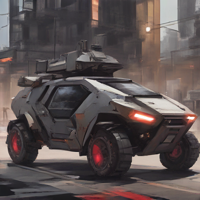

actual_winner_image:


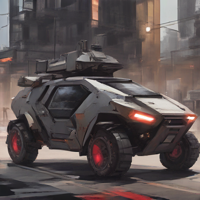

In [66]:
# Compare the recovered winner to the actual winner
recovered_winner_image = generate_image(prompt, input.winner_latent)
print("recovered_winner_image:")
display(recovered_winner_image.resize((200,200)))

# Load from winner_row["image_path"]
actual_winner_image_path = Path(f"results/{winner_row['image_path'].item()}")
actual_winner_image = Image.open(actual_winner_image_path)
print("actual_winner_image:")
display(actual_winner_image.resize((200,200)))


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

recovered loser images:


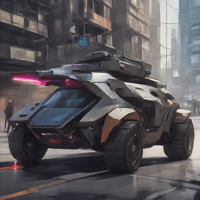

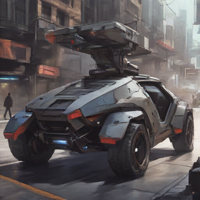

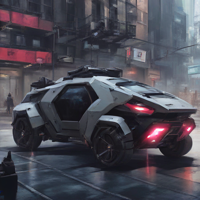

actual loser images:


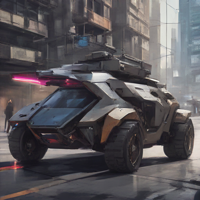

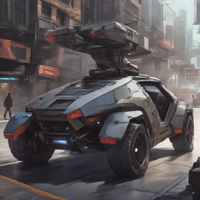

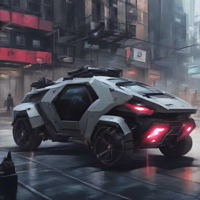

In [67]:
# Compare the recovered losers to the actual losers
recovered_loser_images = [generate_image(prompt, latent) for latent in input.loser_latents]
actual_loser_images = [Image.open(Path(f"results/{row['image_path']}")) for _, row in loser_rows.iterrows()]

# display
print("recovered loser images:")
for recovered_loser_image in recovered_loser_images:
    display(recovered_loser_image.resize((200,200)))

print("actual loser images:")
for actual_loser_image in actual_loser_images:
    display(actual_loser_image.resize((200,200)))
